In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("Seluruh library berhasil dimuat")

Seluruh library berhasil dimuat


In [8]:
df_retail = pd.read_csv("retail_product_dataset_300.csv")
df_retail.info()

print("Ukuran dataset (baris, kolom):", df_retail.shape)
print("\nCuplikan 5 baris teratas:")
display(df_retail.head())
display(df_retail.describe())

<class 'pandas.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   category  300 non-null    str    
 1   price     292 non-null    float64
 2   rating    287 non-null    float64
 3   stock     293 non-null    str    
 4   discount  286 non-null    float64
dtypes: float64(3), str(2)
memory usage: 11.8 KB
Ukuran dataset (baris, kolom): (300, 5)

Cuplikan 5 baris teratas:


,category,price,rating,stock,discount
0,Beauty,477.01,1.2,In Stock,0.0
1,Sports,172.07,2.1,Out of Stock,25.0
2,Home & Kitchen,280.85,1.1,In Stock,10.0
3,Sports,290.42,3.0,NaN,15.0
4,Sports,490.36,2.9,In Stock,0.0


,price,rating,discount
count,292.000000,287.000000,286.000000
mean,247.745822,3.022648,14.947552
std,140.561450,1.123529,10.074148
min,12.540000,1.000000,0.000000
25%,132.592500,2.100000,5.000000
50%,233.075000,3.100000,15.000000
75%,361.562500,3.900000,25.000000
max,498.010000,5.000000,30.000000


In [9]:
total_kosong = df_retail.isnull().sum().sum()
print("Total nilai yang hilang (missing):", total_kosong)

total_duplikat = df_retail.duplicated().sum()
print("Total baris terduplikasi:", total_duplikat)

Total nilai yang hilang (missing): 42
Total baris terduplikasi: 0


In [10]:
from sklearn.impute import SimpleImputer

# Mengubah kolom stock menjadi dummy
df_model = pd.get_dummies(
    df_retail,
    columns=["stock"],
    drop_first=True
)

# Memisahkan fitur dan target
fitur = df_model.drop(columns=["category"])
target = df_model["category"]

# Memastikan seluruh fitur bertipe numerik
fitur = fitur.apply(pd.to_numeric, errors="coerce")

# Mengecek jumlah missing value sebelum imputasi
print("Missing value sebelum imputasi:")
print(fitur.isnull().sum())

# Mengisi missing value dengan nilai median setiap kolom
imputer = SimpleImputer(strategy="median")

fitur_imputasi = imputer.fit_transform(fitur)

# Mengembalikan hasil imputasi menjadi DataFrame
fitur = pd.DataFrame(
    fitur_imputasi,
    columns=fitur.columns,
    index=fitur.index
)

# Mengecek kembali missing value
print("\nMissing value setelah imputasi:")
print(fitur.isnull().sum().sum())

print("\nKolom fitur yang dipakai:")
print(list(fitur.columns))

print(f"\nDimensi fitur : {fitur.shape}")
print(f"Dimensi target : {target.shape}")

Missing value sebelum imputasi:
price                  8
rating                13
discount              14
stock_Low Stock        0
stock_Out of Stock     0
dtype: int64

Missing value setelah imputasi:
0

Kolom fitur yang dipakai:
['price', 'rating', 'discount', 'stock_Low Stock', 'stock_Out of Stock']

Dimensi fitur : (300, 5)
Dimensi target : (300,)


In [11]:
from sklearn.model_selection import train_test_split

fitur_latih, fitur_uji, target_latih, target_uji = train_test_split(
    fitur, target, test_size=0.2, random_state=42, stratify=target
)

print(f"Banyak data latih : {len(fitur_latih)} baris")
print(f"Banyak data uji   : {len(fitur_uji)} baris")

print("\nSebaran proporsi kelas pada data latih:")
print(target_latih.value_counts(normalize=True).round(4))

print("\nSebaran proporsi kelas pada data uji:")
print(target_uji.value_counts(normalize=True).round(4))

Banyak data latih : 240 baris
Banyak data uji   : 60 baris

Sebaran proporsi kelas pada data latih:
category
Beauty            0.2458
Electronics       0.2292
Home & Kitchen    0.2083
Sports            0.1625
Clothing          0.1542
Name: proportion, dtype: float64

Sebaran proporsi kelas pada data uji:
category
Beauty            0.2500
Electronics       0.2333
Home & Kitchen    0.2167
Sports            0.1500
Clothing          0.1500
Name: proportion, dtype: float64


In [12]:
from sklearn.naive_bayes import GaussianNB

model_nb = GaussianNB()
model_nb.fit(fitur_latih, target_latih)

tabel_prior = pd.DataFrame({
    "Kelas": model_nb.classes_,
    "Probabilitas Prior": model_nb.class_prior_
})

display(tabel_prior)

,Kelas,Probabilitas Prior
0,Beauty,0.245833
1,Clothing,0.154167
2,Electronics,0.229167
3,Home & Kitchen,0.208333
4,Sports,0.162500


In [13]:
tabel_rerata = pd.DataFrame(
    model_nb.theta_,
    index=model_nb.classes_,
    columns=fitur.columns
)
print("Parameter Rata-Rata (mean) Tiap Fitur per Kelas:")
display(tabel_rerata.round(2))

tabel_varians = pd.DataFrame(
    model_nb.var_,
    index=model_nb.classes_,
    columns=fitur.columns
)
print("\nParameter Varians Tiap Fitur per Kelas:")
display(tabel_varians.round(2))

Parameter Rata-Rata (mean) Tiap Fitur per Kelas:


,price,rating,discount,stock_Low Stock,stock_Out of Stock
Beauty,247.01,3.24,15.08,0.10,0.14
Clothing,240.59,3.14,14.19,0.05,0.24
Electronics,240.89,2.89,14.27,0.18,0.22
Home & Kitchen,253.88,2.94,16.30,0.10,0.28
Sports,263.39,2.91,13.97,0.10,0.23



Parameter Varians Tiap Fitur per Kelas:


,price,rating,discount,stock_Low Stock,stock_Out of Stock
Beauty,17495.36,1.13,97.87,0.09,0.12
Clothing,19571.00,0.79,88.53,0.05,0.18
Electronics,21649.55,1.19,96.74,0.15,0.17
Home & Kitchen,16586.73,1.29,99.81,0.09,0.20
Sports,23397.89,1.34,89.97,0.09,0.18


In [14]:
peluang_prediksi = model_nb.predict_proba(fitur_uji)
label_prediksi = model_nb.predict(fitur_uji)

kolom_peluang = {f"P({kelas} | X)": peluang_prediksi[:5, i] for i, kelas in enumerate(model_nb.classes_)}

tabel_cuplikan = pd.DataFrame({
    **kolom_peluang,
    "Prediksi Model": label_prediksi[:5],
    "Label Asli": target_uji.iloc[:5].values
})

display(tabel_cuplikan.round(4))

,P(Beauty | X),P(Clothing | X),P(Electronics | X),P(Home & Kitchen | X),P(Sports | X),Prediksi Model,Label Asli
0,0.2476,0.1305,0.2044,0.2185,0.1990,Beauty,Electronics
1,0.4118,0.1526,0.1262,0.1661,0.1433,Beauty,Beauty
2,0.3776,0.2030,0.1298,0.1753,0.1142,Beauty,Beauty
3,0.0714,0.3101,0.1775,0.2981,0.1428,Clothing,Beauty
4,0.3521,0.2266,0.1370,0.1711,0.1131,Beauty,Beauty


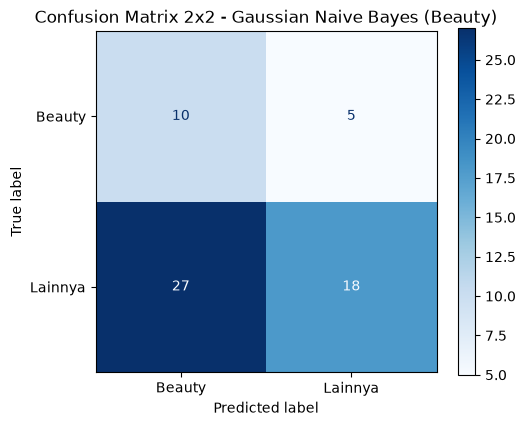

Rekap jumlah prediksi benar per kelas (elemen diagonal):
  Kelas Beauty diprediksi benar sebanyak : 10 data
  Kelas Lainnya diprediksi benar sebanyak : 18 data


In [15]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

kelas_positif = model_nb.classes_[0]

target_uji_biner = np.where(target_uji == kelas_positif, kelas_positif, 'Lainnya')
label_prediksi_biner = np.where(label_prediksi == kelas_positif, kelas_positif, 'Lainnya')

matriks_konfusi_2x2 = confusion_matrix(target_uji_biner, label_prediksi_biner, labels=[kelas_positif, 'Lainnya'])

gambar, sumbu = plt.subplots(figsize=(5.5, 4.5))
tampil_cm = ConfusionMatrixDisplay(confusion_matrix=matriks_konfusi_2x2, display_labels=[kelas_positif, 'Lainnya'])
tampil_cm.plot(cmap="Blues", ax=sumbu, values_format="d")
plt.title(f"Confusion Matrix 2x2 - Gaussian Naive Bayes ({kelas_positif})")
plt.grid(False)
plt.show()

print("Rekap jumlah prediksi benar per kelas (elemen diagonal):")
for i, kelas in enumerate([kelas_positif, 'Lainnya']):
    print(f"  Kelas {kelas} diprediksi benar sebanyak : {matriks_konfusi_2x2[i, i]} data")

In [16]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

akurasi = accuracy_score(target_uji, label_prediksi)
presisi = precision_score(target_uji, label_prediksi, average="macro", zero_division=0)
recall_val = recall_score(target_uji, label_prediksi, average="macro", zero_division=0)
skor_f1 = f1_score(target_uji, label_prediksi, average="macro", zero_division=0)

print(f"Akurasi Total       : {akurasi:.4f} ({akurasi*100:.2f}%)")
print(f"Presisi (macro)     : {presisi:.4f}")
print(f"Recall (macro)      : {recall_val:.4f}")
print(f"F1-Score (macro)    : {skor_f1:.4f}")

print("\nRincian Laporan Klasifikasi:")
print(classification_report(target_uji, label_prediksi, digits=4, zero_division=0))

Akurasi Total       : 0.2000 (20.00%)
Presisi (macro)     : 0.0826
Recall (macro)      : 0.1641
F1-Score (macro)    : 0.1066

Rincian Laporan Klasifikasi:
                precision    recall  f1-score   support

        Beauty     0.2703    0.6667    0.3846        15
      Clothing     0.0000    0.0000    0.0000         9
   Electronics     0.0000    0.0000    0.0000        14
Home & Kitchen     0.1429    0.1538    0.1481        13
        Sports     0.0000    0.0000    0.0000         9

      accuracy                         0.2000        60
     macro avg     0.0826    0.1641    0.1066        60
  weighted avg     0.0985    0.2000    0.1283        60



In [17]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

daftar_model = {
    "Naive Bayes": GaussianNB(),
    "Decision Tree": DecisionTreeClassifier(criterion="gini", max_depth=5, random_state=42),
    "KNN": Pipeline([
        ("penyeragam_skala", StandardScaler()),
        ("knn", KNeighborsClassifier(n_neighbors=5, metric="euclidean"))
    ]),
    "Logistic Regression": Pipeline([
        ("penyeragam_skala", StandardScaler()),
        ("logistik", LogisticRegression(max_iter=1000, random_state=42))
    ]),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "SVM": Pipeline([
        ("penyeragam_skala", StandardScaler()),
        ("svm", SVC(kernel="rbf", probability=True, random_state=42))
    ])
}

In [18]:
rekap_evaluasi = []

for nama_algoritme, model in daftar_model.items():
    model.fit(fitur_latih, target_latih)
    hasil_prediksi = model.predict(fitur_uji)

    rekap_evaluasi.append({
        "Algoritme": nama_algoritme,
        "Accuracy": accuracy_score(target_uji, hasil_prediksi),
        "Precision": precision_score(target_uji, hasil_prediksi, average="macro", zero_division=0),
        "Recall": recall_score(target_uji, hasil_prediksi, average="macro", zero_division=0),
        "F1-Score": f1_score(target_uji, hasil_prediksi, average="macro", zero_division=0)
    })

tabel_rekap = pd.DataFrame(rekap_evaluasi)

print("===== RINGKASAN EVALUASI SELURUH ALGORITME KLASIFIKASI =====")
display(tabel_rekap.round(4))

===== RINGKASAN EVALUASI SELURUH ALGORITME KLASIFIKASI =====


c:\Users\Nadhif\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


,Algoritme,Accuracy,Precision,Recall,F1-Score
0,Naive Bayes,0.2000,0.0826,0.1641,0.1066
1,Decision Tree,0.1667,0.1591,0.1571,0.1517
2,KNN,0.2000,0.1382,0.1640,0.1467
3,Logistic Regression,0.2500,0.1402,0.2070,0.1589
4,Random Forest,0.2000,0.1614,0.1769,0.1673
5,SVM,0.2167,0.1200,0.1793,0.1407


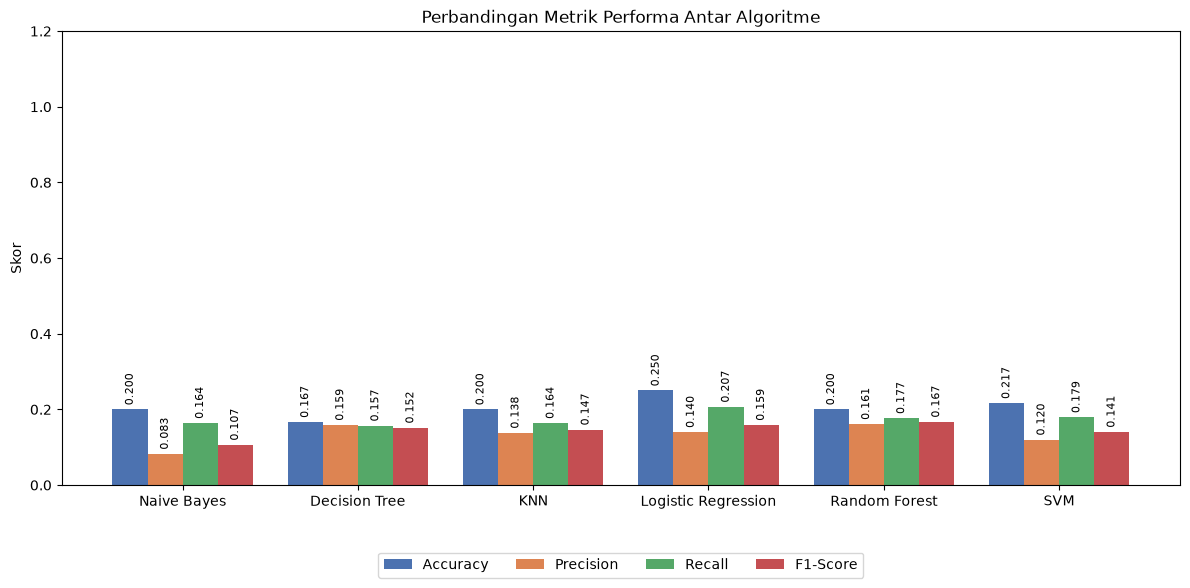

In [19]:
posisi_x = np.arange(len(tabel_rekap["Algoritme"]))
lebar_bar = 0.2

gambar, sumbu = plt.subplots(figsize=(12, 6))

batang1 = sumbu.bar(posisi_x - 1.5*lebar_bar, tabel_rekap["Accuracy"], lebar_bar, label="Accuracy", color="#4c72b0")
batang2 = sumbu.bar(posisi_x - 0.5*lebar_bar, tabel_rekap["Precision"], lebar_bar, label="Precision", color="#dd8452")
batang3 = sumbu.bar(posisi_x + 0.5*lebar_bar, tabel_rekap["Recall"], lebar_bar, label="Recall", color="#55a868")
batang4 = sumbu.bar(posisi_x + 1.5*lebar_bar, tabel_rekap["F1-Score"], lebar_bar, label="F1-Score", color="#c44e52")

sumbu.set_ylabel("Skor")
sumbu.set_title("Perbandingan Metrik Performa Antar Algoritme")
sumbu.set_xticks(posisi_x)
sumbu.set_xticklabels(tabel_rekap["Algoritme"])
sumbu.legend(loc="lower center", bbox_to_anchor=(0.5, -0.22), ncol=4)

def beri_label(kumpulan_batang):
    for batang in kumpulan_batang:
        tinggi = batang.get_height()
        sumbu.annotate(f"{tinggi:.3f}",
                        xy=(batang.get_x() + batang.get_width() / 2, tinggi),
                        xytext=(0, 3),
                        textcoords="offset points",
                        ha="center", va="bottom", fontsize=8, rotation=90)

beri_label(batang1)
beri_label(batang2)
beri_label(batang3)
beri_label(batang4)

plt.ylim(0, 1.2)
plt.tight_layout()
plt.show()

Algoritme dengan performa paling unggul adalah: Random Forest


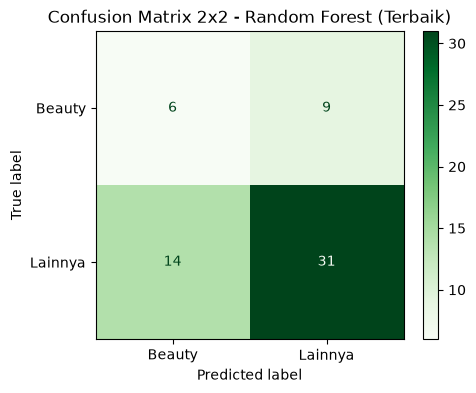

In [20]:
idxmax_f1 = tabel_rekap["F1-Score"].idxmax()
nama_model_terbaik = tabel_rekap.loc[idxmax_f1, "Algoritme"]
model_terbaik = daftar_model[nama_model_terbaik]

print(f"Algoritme dengan performa paling unggul adalah: {nama_model_terbaik}")

prediksi_model_terbaik = model_terbaik.predict(fitur_uji)
prediksi_biner_terbaik = np.where(prediksi_model_terbaik == kelas_positif, kelas_positif, 'Lainnya')

matriks_konfusi_2x2_terbaik = confusion_matrix(target_uji_biner, prediksi_biner_terbaik, labels=[kelas_positif, 'Lainnya'])

gambar, sumbu = plt.subplots(figsize=(5, 4))
tampil_cm_terbaik = ConfusionMatrixDisplay(confusion_matrix=matriks_konfusi_2x2_terbaik, display_labels=[kelas_positif, 'Lainnya'])
tampil_cm_terbaik.plot(cmap="Greens", ax=sumbu, values_format="d")
plt.title(f"Confusion Matrix 2x2 - {nama_model_terbaik} (Terbaik)")
plt.grid(False)
plt.show()